# Olist Brazilian E-Commerce — End-to-End Sales Dashboard

**Dataset**: [Olist Brazilian E-Commerce](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) (Kaggle)
**Difficulty**: Advanced | **Est. time**: 4-6 weeks | **Capstone project**

Fifth and final project in the [data-analysts-projects-101](../README.md) series, and the
capstone: a genuine multi-table ETL + KPI + cohort-retention + logistics analysis over 9 joined
tables and ~100k real orders — the closest thing in this repo to what a data analyst actually does
on day one of a new job.

**Setup is two steps for this project specifically** (every other project only needs one):
```bash
python download_data.py    # pulls the 9 raw CSVs into ./data/
python load_to_duckdb.py   # loads them into a single data/olist.duckdb file
```
Every query in [`queries.sql`](./queries.sql) then reads from that one persisted DuckDB file
instead of re-parsing CSVs on every run — the ETL step the doc specifically calls for.

**A schema gotcha worth knowing up front**: `customer_id` in this dataset is generated *per order*
— a returning customer gets a brand-new `customer_id` every time they buy. The stable,
person-level identifier is `customer_unique_id` on the `customers` table. Every retention /
lifetime-value / repeat-purchase query below joins through `customer_unique_id`, not `customer_id`
— getting this wrong is the single easiest mistake to make with this dataset, and it will silently
make "repeat purchase rate" look like 0% if you use the wrong column.


In [1]:
import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import db

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

con = db.get_connection()


## 1. Headline KPIs


In [2]:
kpi_df = db.run_query("kpi_summary", con)
kpi_df


,total_orders,total_customers,total_revenue,avg_order_value
0,96477,93357,15422461.77,159.86


~96.5k delivered orders, ~93.4k distinct customers (by `customer_unique_id`), R$15.4M total
revenue, R$159.86 average order value.


## 2. Monthly revenue & month-over-month growth

The doc's headline query: `LAG()` for MoM growth. Worth checking the raw data before trusting the
chart, though — Olist only has a handful of seed orders before 2017, which would make the first
couple of % growth figures meaningless (a -100% drop followed by a +649,979% "rebound") if plotted
as-is.


In [3]:
monthly_df = db.run_query("monthly_revenue_growth", con)
print("Orders before 2017:")
display(monthly_df[monthly_df["month"] < "2017-01-01"])

# Excluding the sparse 2016 seed data from here on — this is a real judgment
# call worth stating explicitly rather than silently dropping rows.
monthly_df = monthly_df[monthly_df["month"] >= "2017-01-01"].reset_index(drop=True)


Orders before 2017:


,month,revenue,order_count,unique_customers,prev_month_revenue,mom_growth_pct
0,2016-10-01,46566.71,265,265,NaN,NaN
1,2016-12-01,19.62,1,1,46566.71,-100.0


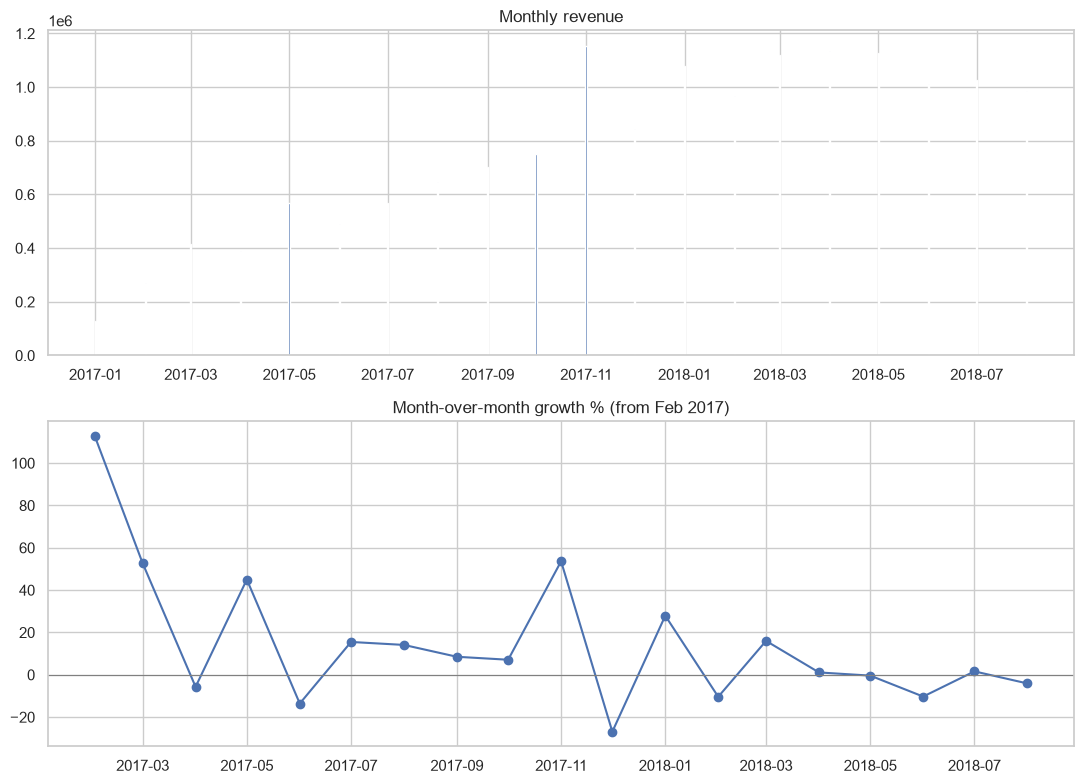

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8))
axes[0].bar(monthly_df["month"], monthly_df["revenue"])
axes[0].set_title("Monthly revenue")

# Jan 2017's growth % is measured against a near-zero Dec 2016 baseline
# (a handful of seed orders), which would dwarf every real month-over-month
# move on the chart — excluded here for the same reason 2016 was excluded above.
growth_df = monthly_df[monthly_df["month"] >= "2017-02-01"]
axes[1].plot(growth_df["month"], growth_df["mom_growth_pct"], marker="o")
axes[1].axhline(0, color="gray", linewidth=0.8)
axes[1].set_title("Month-over-month growth % (from Feb 2017)")
plt.tight_layout()
plt.show()


**Finding**: revenue grows steadily from early 2017 through late 2017, then roughly plateaus
through most of 2018 — consistent with Olist's known growth trajectory before the dataset's
snapshot ends.


## 3. Top categories by revenue

Joins `order_items` -> `products` -> `category_translation` (the raw category names are
Portuguese) -> `order_reviews`, aggregating revenue, items sold, and average rating per category.


,category,orders,items_sold,revenue,avg_item_price,avg_rating
0,health_beauty,8836,9727,1263138.54,129.86,4.14
1,watches_gifts,5624,6001,1206075.33,200.98,4.02
2,bed_bath_table,9417,11270,1050936.61,93.25,3.90
3,sports_leisure,7720,8700,993656.51,114.21,4.11
4,computers_accessories,6689,7894,919640.54,116.50,3.93
5,furniture_decor,6449,8415,736282.47,87.50,3.90
6,cool_stuff,3632,3806,637258.51,167.44,4.15
7,housewares,5884,6989,634542.60,90.79,4.06
8,auto,3897,4256,594363.10,139.65,4.07
9,garden_tools,3518,4361,486432.45,111.54,4.04


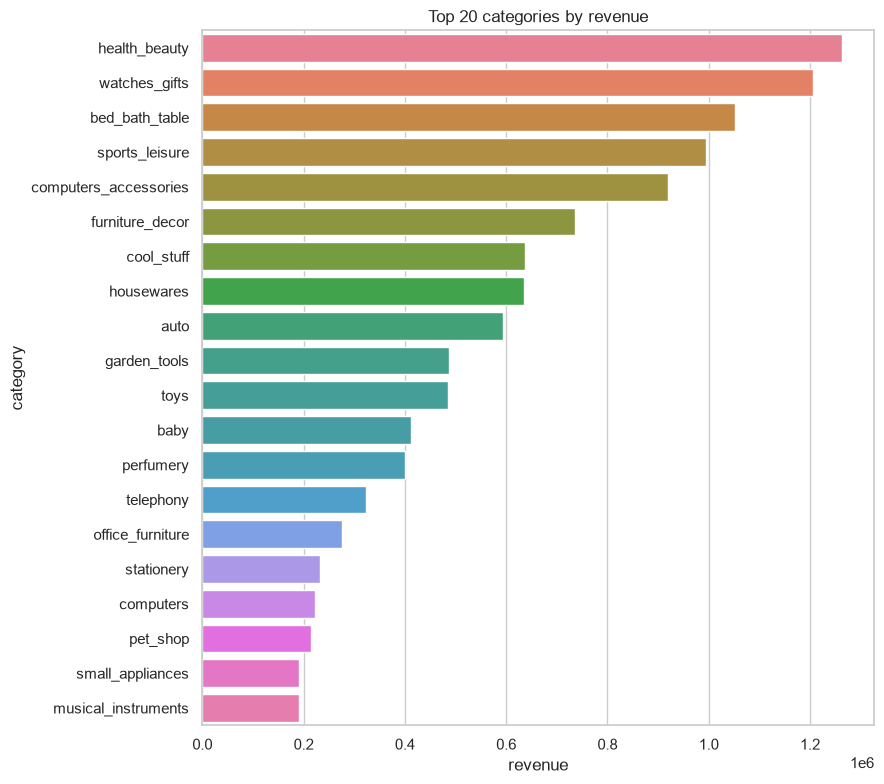

In [5]:
cat_df = db.run_query("top_categories", con)
display(cat_df.head(10))

fig, ax = plt.subplots(figsize=(9, 8))
sns.barplot(cat_df, x="revenue", y="category", hue="category", legend=False, ax=ax)
ax.set_title("Top 20 categories by revenue")
plt.tight_layout()
plt.show()


## 4. Delivery / logistics performance


,avg_delivery_days,avg_days_before_estimate,late_pct
0,12.5,11.88,8.11


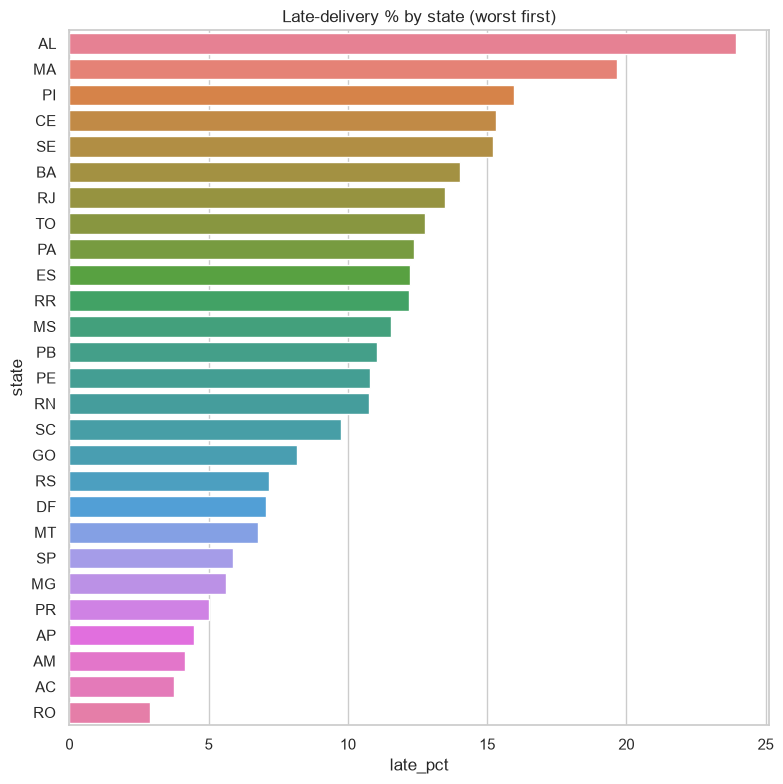

In [6]:
fulfillment_df = db.run_query("order_fulfillment_summary", con)
display(fulfillment_df)

regional_df = db.run_query("regional_fulfillment", con)
fig, ax = plt.subplots(figsize=(8, 8))
sns.barplot(
    regional_df.sort_values("late_pct", ascending=False),
    x="late_pct", y="state", hue="state", legend=False, ax=ax,
)
ax.set_title("Late-delivery % by state (worst first)")
plt.tight_layout()
plt.show()


**Finding**: average delivery takes ~12.5 days, and Olist beats its own estimated delivery date by
~12 days on average (the estimate is deliberately conservative) — but only ~8% of orders arrive
late overall. Late-delivery rates vary substantially by state, with several northern/northeastern
states (further from the main São Paulo logistics hub) showing 2-3x the late rate of the best
-performing states.


## 5. Repeat purchase rate & cohort retention

This is where the `customer_unique_id` vs. `customer_id` distinction matters most — get it wrong
and every number below is meaningless.


In [7]:
repeat_df = db.run_query("repeat_purchase_rate", con)
repeat_df


,total_customers,repeat_customers,repeat_purchase_rate_pct
0,93358,2801.0,3.0


**Finding — and it's a big one**: only ~3% of customers ever place a second order. This is a
well-documented, real characteristic of the Olist dataset (most sellers on the platform are
small/independent, and Olist itself is a marketplace connector rather than a single retailer
customers return to by brand loyalty) — not a bug in the query. It's exactly the kind of number
that changes a business conversation: growth here is almost entirely driven by new-customer
acquisition, not retention, so a cohort-retention chart is expected to look sparse.


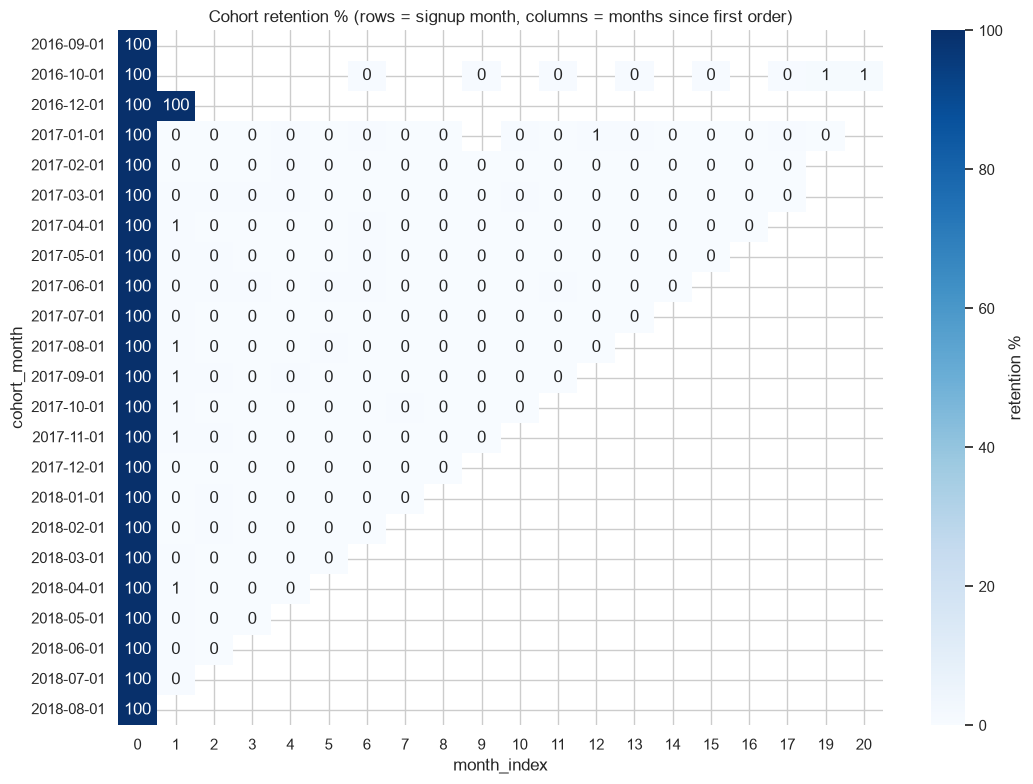

In [8]:
cohort_df = db.run_query("monthly_cohort_retention", con)
cohort_df["cohort_month"] = cohort_df["cohort_month"].astype(str)

pivot = cohort_df.pivot(index="cohort_month", columns="month_index", values="active_customers")
cohort_size = pivot[0]
retention_pct = pivot.div(cohort_size, axis=0).round(3) * 100

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(retention_pct, annot=True, fmt=".0f", cmap="Blues", ax=ax, cbar_kws={"label": "retention %"})
ax.set_title("Cohort retention % (rows = signup month, columns = months since first order)")
plt.tight_layout()
plt.show()


**Finding**: retention drops to low single digits by month 1 for essentially every cohort,
confirming the 3% repeat-purchase number above from a different angle. Worth stating plainly in any
write-up: this dataset is not a good candidate for a "retention improved X%" narrative — the honest
finding is "retention is structurally low here, and acquisition is what drives growth."


## 6. Payment methods & top customers by lifetime value


In [9]:
pay_df = db.run_query("payment_type_breakdown", con)
display(pay_df)

ltv_df = db.run_query("top_customers_by_ltv", con)
ltv_df.head(10)


,payment_type,order_count,total_revenue,avg_installments
0,credit_card,76505,12542084.19,3.51
1,boleto,19784,2869361.27,1.00
2,voucher,3866,379436.87,1.00
3,debit_card,1528,217989.79,1.00
4,not_defined,3,0.00,1.00


,customer_unique_id,customer_state,order_count,lifetime_value
0,0a0a92112bd4c708ca5fde585afaa872,RJ,1,13664.08
1,da122df9eeddfedc1dc1f5349a1a690c,RJ,2,7571.63
2,763c8b1c9c68a0229c42c9fc6f662b93,ES,1,7274.88
3,dc4802a71eae9be1dd28f5d788ceb526,MS,1,6929.31
4,459bef486812aa25204be022145caa62,ES,1,6922.21
5,ff4159b92c40ebe40454e3e6a7c35ed6,SP,1,6726.66
6,4007669dec559734d6f53e029e360987,MG,1,6081.54
7,eebb5dda148d3893cdaf5b5ca3040ccb,SP,1,4764.34
8,48e1ac109decbb87765a3eade6854098,PB,1,4681.78
9,c8460e4251689ba205045f3ea17884a1,RS,4,4655.91


**Finding**: credit card dominates both order count and revenue share, with a meaningfully higher
average installment count than other payment types — consistent with larger basket sizes being
financed rather than paid upfront.

## Key takeaways

- Revenue grew steadily through 2017 before plateauing in 2018 — but the first two months of the
  raw data (2016) are seed-data noise that would wreck a naive MoM growth chart if not excluded.
- `customer_id` is per-order, not per-customer, in this dataset — every retention/CLV query must
  join through `customer_unique_id` instead, or the numbers are silently wrong.
- Repeat purchase rate is ~3% — a real, well-documented characteristic of this marketplace dataset,
  not a query bug. Growth here is acquisition-driven, not retention-driven.
- Late-delivery rate is ~8% overall but varies 2-3x by state, concentrated in regions further from
  the main logistics hub.

## Next steps
```bash
streamlit run app.py
```
